In [8]:
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Point, LineString


%matplotlib inline

# Allow inline jshtml animations
from matplotlib import rc
rc('animation', html='jshtml')

import anuga 
meshfile = 'merimbula_43200.tsh'
#meshfile = 'merimbula_17156.tsh'
#meshfile = 'merimbula_10785.tsh'

newmesh = anuga.pmesh.mesh.importMeshFromFile(meshfile)

newmesh



        mesh Triangles: [[3823, 3836, 346], [345, 3838, 3837], [5133, 5140, 5132], [535, 702, 701], [3739, 3727, 3737], [5108, 5110, 5109], [3610, 3591, 3613], [3774, 3757, 3773], [1010, 1039, 452], [3760, 341, 3758], [443, 442, 673], [670, 415, 681], [639, 352, 1642], [74, 696, 485], [675, 902, 417], [353, 867, 865], [1041, 641, 644], [3598, 3606, 489], [2545, 3583, 2543], [862, 83, 82], [350, 349, 510], [655, 657, 658], [2745, 2747, 2744], [1639, 1007, 2544], [3592, 481, 3590], [718, 736, 716], [587, 578, 585], [794, 602, 592], [4891, 3680, 3682], [795, 595, 593], [13591, 13596, 13594], [550, 602, 794], [3750, 3790, 3791], [579, 572, 583], [3722, 3723, 3741], [568, 569, 593], [619, 612, 590], [3828, 3749, 3767], [6990, 7002, 6989], [482, 438, 655], [3786, 3785, 3784], [797, 632, 614], [6988, 6989, 336], [424, 490, 658], [3659, 3663, 3635], [5955, 5956, 5924], [5943, 5924, 5936], [630, 632, 628], [3663, 3670, 3635], [1646, 1648, 1645], [408, 871, 1044], [359, 509, 360], [3605, 3606, 

newmesh

In [9]:
print(len(newmesh.getMeshSegmentTags()))
print(len(newmesh.getMeshSegments()))
print(len(newmesh.getUserSegments()))
print(newmesh.getMeshSegments().tolist())

meshsegmenttags = newmesh.getMeshSegmentTags()
meshvertices = newmesh.getMeshVertices().tolist()
usersegments = newmesh.getUserSegments()
meshsegments = newmesh.getMeshSegments().tolist()


1072
1072
468
[[3, 18039], [9, 15602], [10, 15589], [31, 30], [13024, 38], [10446, 45], [61, 60], [63, 64], [72, 71], [695, 72], [74, 487], [607, 79], [83, 82], [857, 84], [2525, 89], [4864, 92], [95, 94], [100, 101], [3500, 103], [121, 6775], [125, 7378], [140, 21658], [151, 11317], [161, 3023], [162, 3053], [163, 3079], [165, 1554], [170, 741], [174, 582], [180, 179], [181, 180], [1239, 181], [185, 2778], [194, 7843], [196, 197], [18443, 232], [235, 12103], [237, 12198], [254, 5099], [266, 267], [267, 1090], [269, 268], [270, 22004], [290, 289], [309, 310], [19259, 327], [330, 7584], [336, 7008], [340, 339], [3760, 341], [348, 347], [356, 1640], [359, 360], [370, 371], [382, 17685], [398, 399], [403, 4175], [405, 1651], [407, 871], [410, 1012], [1035, 413], [421, 420], [423, 424], [427, 649], [433, 434], [436, 435], [437, 656], [438, 908], [440, 887], [881, 441], [1036, 447], [450, 1014], [455, 5061], [456, 10161], [463, 464], [464, 14125], [69, 70], [75, 507], [76, 77], [77, 78], [6

In [10]:
for i, tag in enumerate(meshsegmenttags):
    if tag == 'open':
        print (i, tag, meshsegments[i], meshvertices[meshsegments[i][0]], meshvertices[meshsegments[i][1]])

21 open [140, 21658] [761052.7, 5912151.0] [761020.932471, 5912154.85021]
468 open [468, 16713] [760330.75, 5912238.5] [760308.189063, 5912241.23438]
469 open [469, 19102] [760691.725, 5912194.75] [760669.164063, 5912197.48438]
855 open [13559, 18966] [759969.775, 5912282.25] [759947.214063, 5912284.98438]
856 open [13475, 20638] [760150.2625, 5912260.375] [760127.701562, 5912263.10938]
881 open [16828, 20624] [760060.01875, 5912271.3125] [760037.457813, 5912274.04688]
882 open [16836, 18995] [760014.896875, 5912276.78125] [759992.335938, 5912279.51563]
883 open [16848, 19019] [760240.50625, 5912249.4375] [760217.945313, 5912252.17188]
884 open [13584, 16958] [760511.2375, 5912216.625] [760488.676563, 5912219.35938]
885 open [16705, 16710] [760285.628125, 5912243.96875] [760263.067187, 5912246.70313]
886 open [16710, 16848] [760263.067187, 5912246.70313] [760240.50625, 5912249.4375]
887 open [13587, 16950] [760420.99375, 5912227.5625] [760398.432813, 5912230.29688]
888 open [16879, 169

In [11]:
for i,seg in enumerate(usersegments):
    if seg.tag == 'open':
        print(i,seg.tag, [seg.vertices[0].x, seg.vertices[0].y], [seg.vertices[1].x, seg.vertices[1].y])

21 open [761052.7, 5912151.0] [759608.8, 5912326.0]


In [13]:
domain = anuga.pmesh_to_domain_instance(meshfile, anuga.Domain, use_cache=True)


Setting omp_num_threads to 1


760882.8 5912276.5


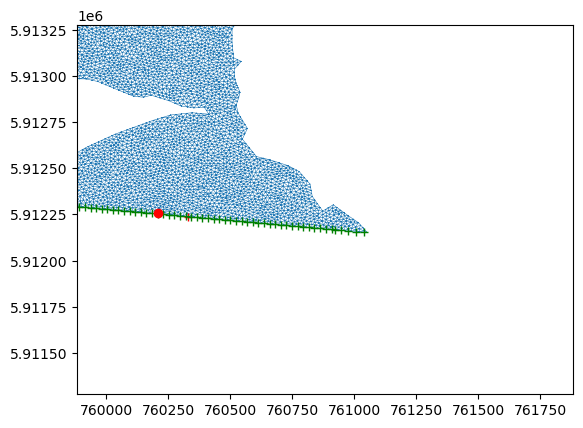

In [ ]:
fig, ax, lines = domain.triplot(linewidth = 0.4)
#ax.set_xlim(761052.7,759608.8)
#ax.set_ylim(5912151.0,5912326.0)


p0 = np.array([761052.7, 5912151.0])
p1 = np.array([759608.8, 5912326.0])

start = Point(p0)
end   = Point(p1)
x0 = 0.5*(p0[0]+p1[0])
y0 = 0.5*(p0[1]+p1[1])
ax.plot(x0,y0,'r+')

ax.set_xlim(x0-1000,x0+1000)
ax.set_ylim(y0-1000,y0+1000)

line = LineString([start, end]) 

for i in range(len(meshsegmenttags)):
    tag = meshsegmenttags[i]

    #meshsegmenttags[i] = 'exterior'
    #if tag == 'open':
    x0 = meshvertices[meshsegments[i][0]][0]
    y0 = meshvertices[meshsegments[i][0]][1]
    x1 = meshvertices[meshsegments[i][1]][0]
    y1 = meshvertices[meshsegments[i][1]][1]

    xm = 0.5*(x0+x1)
    ym = 0.5*(y0+y1)

    q0 = Point(xm,ym)
    
    #if (line.distance(q0) < 1.0e-2) and (line.project(q0)/line.length):
    if (line.distance(q0) < 1.0e-2):
        if (line.project(q0)/line.length > 0.0) and (line.project(q0)/line.length < 1.0):
            #print(tag,xm,ym,line.distance(q0), line.project(q0)/line.length)
            #meshsegmenttags[i] = 'open'
            ax.plot(xm,ym,'g+')
        else:
            ax.plot(xm,ym,'b+')
            print(tag,xm,ym,line.distance(q0), line.project(q0)/line.length)
    elif tag == 'exterior':
        pass
    else:
        print("Problem")

#ax.set_xlim(759608.8,761052.7)
#ax.set_ylim(5912151.0,5912326.0)



print (x0,y0)

ax.plot(760209.6379, 5912258.4398, 'ro') # North end of Merimbula Lake
plt.show()

[-5.74000000e-01 -5.74960961e-01 -5.75921922e-01 -5.76882883e-01
 -5.77843844e-01 -5.78804805e-01 -5.79765766e-01 -5.80726727e-01
 -5.81687688e-01 -5.82648649e-01 -5.83609610e-01 -5.84000000e-01
 -5.84000000e-01 -5.84000000e-01 -5.84000000e-01 -5.84000000e-01
 -5.84000000e-01 -5.84000000e-01 -5.84000000e-01 -5.84000000e-01
 -5.84000000e-01 -5.83279279e-01 -5.79435435e-01 -5.75591592e-01
 -5.71747748e-01 -5.67903904e-01 -5.64060060e-01 -5.60216216e-01
 -5.56372372e-01 -5.52528529e-01 -5.48684685e-01 -5.44840841e-01
 -5.37993994e-01 -5.30306306e-01 -5.22618619e-01 -5.14930931e-01
 -5.07243243e-01 -4.99555556e-01 -4.91867868e-01 -4.84180180e-01
 -4.76492492e-01 -4.68804805e-01 -4.64720721e-01 -4.66642643e-01
 -4.68564565e-01 -4.70486486e-01 -4.72408408e-01 -4.74330330e-01
 -4.76252252e-01 -4.78174174e-01 -4.80096096e-01 -4.82018018e-01
 -4.83939940e-01 -4.80276276e-01 -4.76432432e-01 -4.72588589e-01
 -4.68744745e-01 -4.64900901e-01 -4.61057057e-01 -4.57213213e-01
 -4.53369369e-01 -4.49525

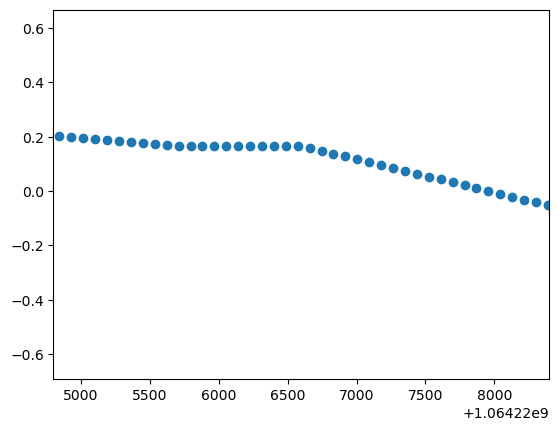

In [ ]:
model_date = 'sept_2003'
model_dir = f'../model_data_{model_date}'
boundary_filename = anuga.join(model_dir,'boundary.csv')
import pandas as pd
from scipy.interpolate import interp1d

tide_df = pd.read_csv(boundary_filename)
tide_function = interp1d(tide_df['timestamp'], tide_df['Stage'], kind='linear', fill_value=0.0, bounds_error=False)

time = np.linspace(tide_df['timestamp'].iloc[0], tide_df['timestamp'].iloc[0]+86400, 1000)
stage = tide_function(time)
#plt.plot(tide_df['timestamp'], tide_df['Stage'], 'o')
plt.plot(time, stage, 'o')
plt.xlim(tide_df['timestamp'].iloc[0]+20*3600, tide_df['timestamp'].iloc[0]+21*3600)

#print(stage)

In [56]:
%ls

anuga_pmesh_gui.log                                merimbula_17156_refined.tsh
meri0.pts                                          merimbula_17156.tsh
meri0.xya                                          merimbula_17540_refined.tsh
merimbula_10785_1.tsh                              merimbula_17540_refined.zip
merimbula_10785_5.msh                              merimbula_43200.tsh
merimbula_10785_5.tsh                              merimbula_bathymetry.pts
merimbula_10785.tsh                                merimbula_bathymetry.xya
merimbula_17156_refined_bathymetry_alpha_0.01.tsh  merimbula_interpolated.zip
merimbula_17156_refined_bathymetry_alpha_0.1.tsh   _plot/
merimbula_17156_refined_bathymetry_alpha_10.tsh    test.tsh
merimbula_17156_refined_bathymetry_alpha_1.tsh     test.txt
merimbula_17156_refined_bathymetry_alpha_pt5.tsh   Untitled.ipynb
